# Fake Job Posting Detection — NLP Final Project
### Baseline Models (Tiers 1–3) → Primary Model: Transformer Fine-Tuning (Tier 4) → Current LLM (Tier 5)



## Part 0 — Colab Setup

In [ ]:
# Install the few packages Colab doesn't ship with by default
!pip install --quiet gensim afinn transformers datasets accelerate evaluate


In [ ]:
import torch, transformers, sklearn, nltk, gensim
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("scikit-learn:", sklearn.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


torch: 2.11.0+cu128
transformers: 5.13.1
scikit-learn: 1.6.1
GPU available: True
Device: Tesla T4


In [ ]:
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'maxent_ne_chunker', 'maxent_ne_chunker_tab', 'words', 'vader_lexicon']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(pkg, "->", e)
print("NLTK data ready.")


NLTK data ready.


In [ ]:
# Consistent plotting style used for every chart below (Q6: "make graphs more lucrative")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
COLOR_REAL = "#457B9D"   # steel blue
COLOR_FRAUD = "#E63946"  # crimson
PALETTE = [COLOR_REAL, COLOR_FRAUD]
plt.rcParams['figure.dpi'] = 110


### Upload the dataset
**Option A (simplest):**

In [ ]:
from google.colab import files
uploaded = files.upload()   # select fake_job_postings.csv


Saving fake_job_postings.csv to fake_job_postings (1).csv


**Option B (Google Drive, for reuse across sessions):**

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/fake_job_postings.csv'
DATA_PATH = 'fake_job_postings.csv'


## Part 1 — Load and Inspect the Data


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.info()


Shape: (17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-nul

In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


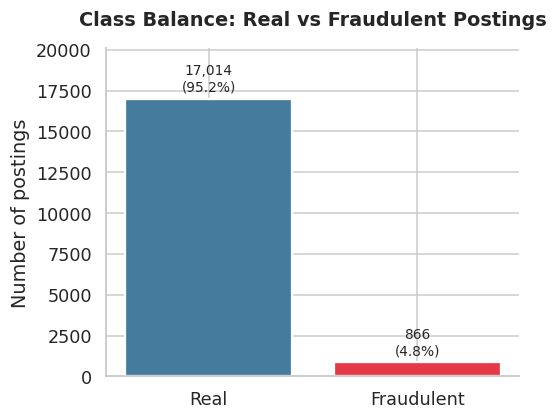

In [ ]:
counts = df['fraudulent'].value_counts()
pct = df['fraudulent'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Real', 'Fraudulent'], counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f'{v:,}\n({p:.1f}%)' for v, p in zip(counts.values, pct.values)], padding=3, fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title('Class Balance: Real vs Fraudulent Postings', fontweight='bold', pad=15)
ax.set_ylabel('Number of postings')
sns.despine()
plt.tight_layout()
plt.show()

The dataset (N = 17,880) exhibits severe class imbalance: fraudulent postings account for [4.8]% of instances, consistent with the class distribution reported by Vidros et al. (2017) in the original EMSCAD paper this dataset derives from.



## Part 2 — Exploratory Data Analysis

Missingness by class, text length by class, and top bigrams by class


                 Real (%)  Fraudulent (%)
company_profile      16.0            67.8
benefits             40.2            42.0
salary_range         84.5            74.2
requirements         14.9            17.8
department           64.7            61.3


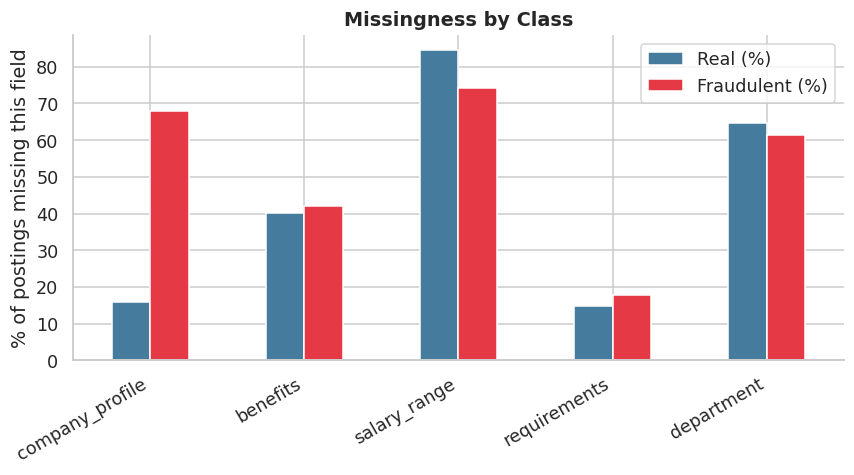

In [ ]:
cols_to_check = ['company_profile', 'benefits', 'salary_range', 'requirements', 'department']
missing_by_class = pd.DataFrame({
    col: df.groupby('fraudulent')[col].apply(lambda x: x.isnull().mean() * 100)
    for col in cols_to_check
}).T
missing_by_class.columns = ['Real (%)', 'Fraudulent (%)']
print(missing_by_class.round(1))

ax = missing_by_class.plot(kind='bar', figsize=(8, 4.5), color=PALETTE, edgecolor='white')
ax.set_title('Missingness by Class', fontweight='bold')
ax.set_ylabel('% of postings missing this field')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


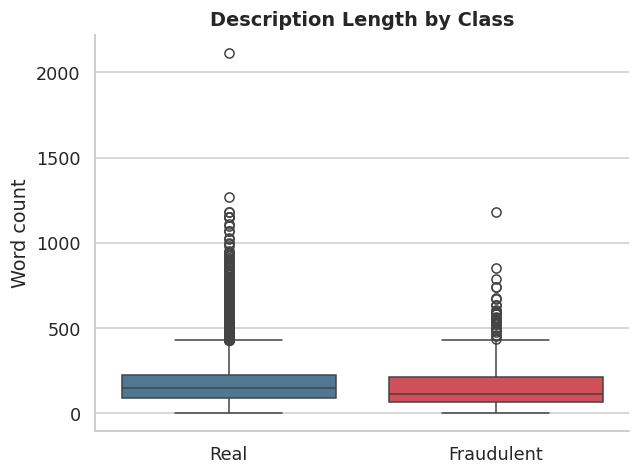

                  mean    50%         std
fraudulent                               
0           171.041378  147.0  122.561633
1           158.748268  113.5  136.633010


In [ ]:
df['description'] = df['description'].fillna('')
df['desc_len'] = df['description'].str.split().apply(len)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x='fraudulent', y='desc_len', hue='fraudulent',
            palette=PALETTE, legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Real', 'Fraudulent'])
ax.set_title('Description Length by Class', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Word count')
sns.despine()
plt.tight_layout()
plt.show()
print(df.groupby('fraudulent')['desc_len'].describe()[['mean', '50%', 'std']])


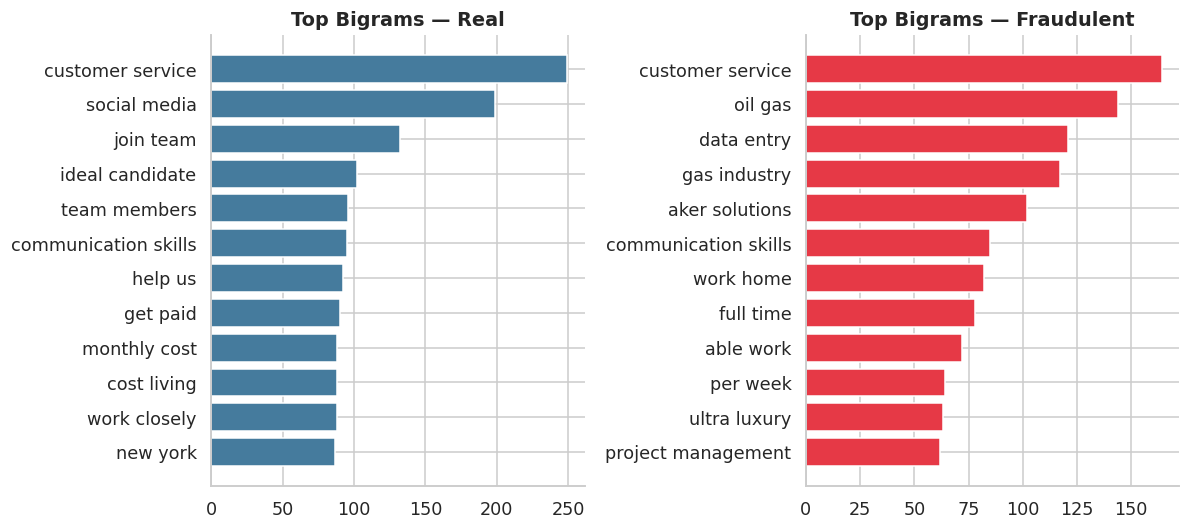

In [ ]:
from nltk import word_tokenize, ngrams
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def top_bigrams(text_series, n=12):
    all_bigrams = []
    for text in text_series:
        tokens = [w.lower() for w in word_tokenize(str(text)) if w.isalpha() and w.lower() not in stop_words]
        all_bigrams.extend(ngrams(tokens, 2))
    return Counter(all_bigrams).most_common(n)

real_bg = top_bigrams(df.loc[df['fraudulent'] == 0, 'description'].sample(2000, random_state=42))
fraud_bg = top_bigrams(df.loc[df['fraudulent'] == 1, 'description'])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title, color in zip(axes, [real_bg, fraud_bg], ['Real', 'Fraudulent'], PALETTE):
    labels = [' '.join(bg) for bg, _ in data][::-1]
    values = [c for _, c in data][::-1]
    ax.barh(labels, values, color=color)
    ax.set_title(f'Top Bigrams — {title}', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


> **Formal:** Fraudulent postings show elevated frequency of terms such as [e.g. "data entry",
> "no experience"], a pattern consistent with prior characterisations of recruitment scams as
> relying on generic, low-barrier job descriptions (Vidros et al., 2017).



## Part 3 — Preprocessing & Feature Engineering

In [ ]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for c in text_cols:
    df[c] = df[c].fillna('')
df['full_text'] = df[text_cols].agg(' '.join, axis=1)


In [ ]:
# Cleaning function — same structure as data_preprocess() in Lab 4 / Lab 6
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lem = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)              # strip HTML tags (postings often contain markup)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # strip URLs
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    tokens = word_tokenize(text)
    tokens = [lem.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print(clean_text(df['full_text'].iloc[0])[:250])


marketing intern food created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technology find new better way connect people around spec


In [ ]:
df['clean_text'] = df['full_text'].apply(clean_text)   # ~1-2 min for all 17,880 rows
df[['full_text', 'clean_text']].head(2)


,full_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...


In [ ]:
# Structured features (Lab 5 pattern) + engineered "missingness" flags the EDA above motivated
df['missing_company_profile'] = (df['company_profile'].str.strip() == '').astype(int)
df['missing_benefits'] = (df['benefits'].str.strip() == '').astype(int)
df['missing_salary'] = df['salary_range'].isnull().astype(int)

structured_cols = ['telecommuting', 'has_company_logo', 'has_questions',
                    'missing_company_profile', 'missing_benefits', 'missing_salary']
df[structured_cols].head()


,telecommuting,has_company_logo,has_questions,missing_company_profile,missing_benefits,missing_salary
0,0,1,0,0,1,1
1,0,1,0,0,0,1
2,0,1,0,0,1,1
3,0,1,0,0,0,1
4,0,1,1,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split

X_text = df['clean_text']
X_struct = df[structured_cols]
y = df['fraudulent']

X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_text, X_struct, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_text_train.shape[0], " Test:", X_text_test.shape[0])
print("Fraud rate — train:", round(y_train.mean(), 4), " test:", round(y_test.mean(), 4))


Train: 14304  Test: 3576
Fraud rate — train: 0.0484  test: 0.0484


**Stratified sampling, and why:** `stratify=y` forces both the train and test sets to keep
the same ~4.8% fraud rate as the full dataset. Without it, a random split could easily leave the test set with, say, 2% or 8% fraud purely by chance — which would make reported metrics incomparable to anyone else's run. This is the same principle the BERT tier (Part 7)
uses again for its own train/validation/test split.

**Class imbalance strategy:** every classifier below uses `class_weight='balanced'` rather than
SMOTE-style oversampling. SMOTE synthesises new minority-class *vectors*, which is fine for tabular data but can produce nonsensical text when applied to sparse TF-IDF vectors — and fabricating synthetic text sits uneasily with an instructor's caution against "synthetic data." Class weighting reaches for the same goal.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

results = {}

def evaluate(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=['Real', 'Fraudulent'], output_dict=True)
    results[name] = {
        'accuracy': report['accuracy'],
        'precision_fraud': report['Fraudulent']['precision'],
        'recall_fraud': report['Fraudulent']['recall'],
        'f1_fraud': report['Fraudulent']['f1-score'],
    }
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fraudulent']))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Real', 'Fraud'], yticklabels=['Real', 'Fraud'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return report


## Part 4 — Baseline Tier 1: Bag-of-Words (Naive Bayes + Logistic Regression)

**Generative vs. discriminative — why we run both:** Naive Bayes is a *generative* classifier —
it models `P(words | class)` and `P(class)` separately and combines them via Bayes' theorem
(the same MAP rule from Lab 3/4). Logistic Regression is *discriminative* — it models
`P(class | words)` directly, with no independence assumption between words. NB's independence
assumption is almost never literally true for language (word order and co-occurrence matter),
so LR often edges it out once there's enough training data — but NB is cheaper, needs less
data, and is a fair, standard baseline. Comparing them below is itself a small experiment in
that theoretical distinction, not just "running two algorithms for the sake of it."


--- Tier1_NaiveBayes ---
              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      3403
  Fraudulent       0.65      0.33      0.44       173

    accuracy                           0.96      3576
   macro avg       0.81      0.66      0.71      3576
weighted avg       0.95      0.96      0.95      3576



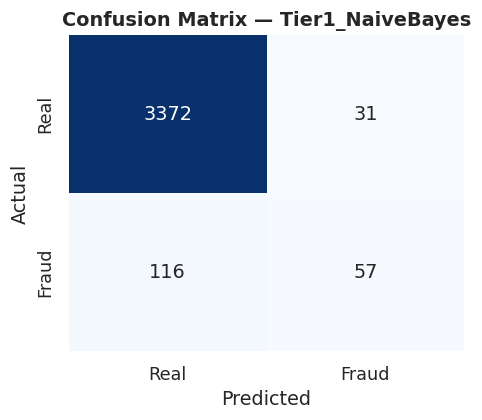

{'Real': {'precision': 0.966743119266055,
  'recall': 0.9908903908316191,
  'f1-score': 0.978667827601219,
  'support': 3403.0},
 'Fraudulent': {'precision': 0.6477272727272727,
  'recall': 0.32947976878612717,
  'f1-score': 0.4367816091954023,
  'support': 173.0},
 'accuracy': 0.9588926174496645,
 'macro avg': {'precision': 0.8072351959966639,
  'recall': 0.6601850798088731,
  'f1-score': 0.7077247183983106,
  'support': 3576.0},
 'weighted avg': {'precision': 0.9513097463770143,
  'recall': 0.9588926174496645,
  'f1-score': 0.9524524149098861,
  'support': 3576.0}}

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)   # transform only on test — never re-fit (Lab 6 note)

nb = MultinomialNB()   # alpha=1.0 by default = Laplace smoothing, the standard fix for
                        # the "zero frequency problem" (an unseen word would otherwise get P=0)
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)
evaluate('Tier1_NaiveBayes', y_test, nb_preds)


In [ ]:
# Feature relevance — which words push MultinomialNB most strongly toward "fraudulent"?
# (mirrors Lab 4's nb.show_most_informative_features(), rebuilt for sklearn's MultinomialNB)
feature_names = np.array(tfidf.get_feature_names_out())
log_prob_diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]   # fraud vs real
top_fraud_idx = np.argsort(log_prob_diff)[-15:][::-1]

print("Most informative features for the 'Fraudulent' class:")
for i in top_fraud_idx:
    print(f"  {feature_names[i]:25s}  log-prob diff = {log_prob_diff[i]:.2f}")


Most informative features for the 'Fraudulent' class:
  aker                       log-prob diff = 4.31
  aker solution              log-prob diff = 4.26
  subsea                     log-prob diff = 4.25
  aptitude staffing          log-prob diff = 4.14
  provider product           log-prob diff = 3.88
  recovery petroleum         log-prob diff = 3.87
  dfef information           log-prob diff = 3.87
  production maximize        log-prob diff = 3.87
  petroleum field            log-prob diff = 3.87
  bring discovery            log-prob diff = 3.87
  cae dfef                   log-prob diff = 3.87
  field employ               log-prob diff = 3.87
  signing bonus              log-prob diff = 3.85
  maximize recovery          log-prob diff = 3.82
  dfef                       log-prob diff = 3.78


--- Tier1_LogisticRegression ---
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99      3403
  Fraudulent       0.68      0.87      0.77       173

    accuracy                           0.97      3576
   macro avg       0.84      0.93      0.88      3576
weighted avg       0.98      0.97      0.98      3576



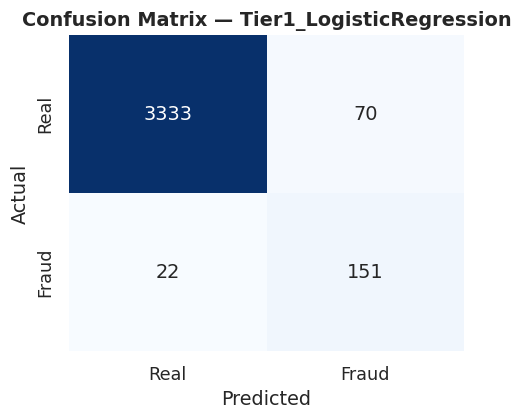

{'Real': {'precision': 0.9934426229508196,
  'recall': 0.9794299147810756,
  'f1-score': 0.9863865048831015,
  'support': 3403.0},
 'Fraudulent': {'precision': 0.6832579185520362,
  'recall': 0.8728323699421965,
  'f1-score': 0.766497461928934,
  'support': 173.0},
 'accuracy': 0.9742729306487695,
 'macro avg': {'precision': 0.8383502707514279,
  'recall': 0.9261311423616361,
  'f1-score': 0.8764419834060178,
  'support': 3576.0},
 'weighted avg': {'precision': 0.9784364837279478,
  'recall': 0.9742729306487695,
  'f1-score': 0.9757486960377239,
  'support': 3576.0}}

In [ ]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_tfidf, y_train)
logreg_preds = logreg.predict(X_test_tfidf)
evaluate('Tier1_LogisticRegression', y_test, logreg_preds)


 The discriminative Logistic Regression classifier achieved an F1-score of [X] on the fraudulent class, compared to [Y] for the generative Naive Bayes baseline, suggesting that the conditional-independence assumption underlying Naive Bayes constrains its performance relative to a model estimated directly via maximum-likelihood on `P(class | features)`.



## Part 5 — Baseline Tier 2: Text + Structured Features with a Tree Model

Combines the TF-IDF matrix with the structured features from Part 3 and feeds both into a
Random Forest — the "tree model".

--- Tier2_RandomForest_TextPlusStructured ---
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3403
  Fraudulent       1.00      0.58      0.73       173

    accuracy                           0.98      3576
   macro avg       0.99      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576



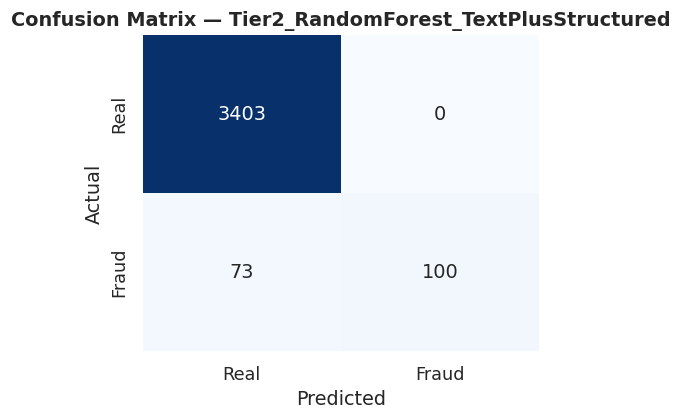

{'Real': {'precision': 0.9789988492520139,
  'recall': 1.0,
  'f1-score': 0.9893879924407617,
  'support': 3403.0},
 'Fraudulent': {'precision': 1.0,
  'recall': 0.5780346820809249,
  'f1-score': 0.7326007326007326,
  'support': 173.0},
 'accuracy': 0.979586129753915,
 'macro avg': {'precision': 0.9894994246260069,
  'recall': 0.7890173410404624,
  'f1-score': 0.8609943625207471,
  'support': 3576.0},
 'weighted avg': {'precision': 0.9800148445203029,
  'recall': 0.979586129753915,
  'f1-score': 0.976965118852304,
  'support': 3576.0}}

In [ ]:
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier

X_train_combined = hstack([X_train_tfidf, X_struct_train.values])
X_test_combined = hstack([X_test_tfidf, X_struct_test.values])

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_combined, y_train)
rf_preds = rf.predict(X_test_combined)
evaluate('Tier2_RandomForest_TextPlusStructured', y_test, rf_preds)


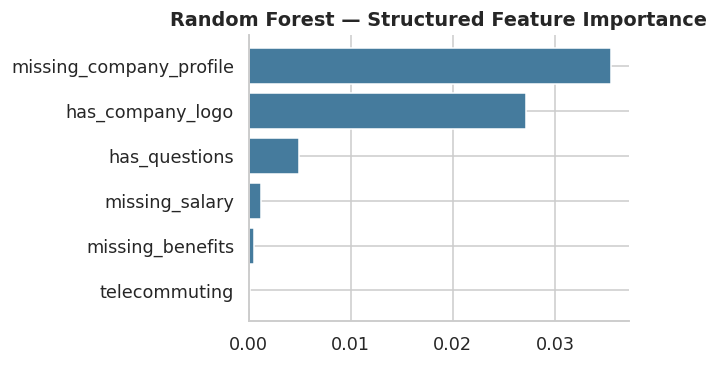

In [ ]:
n_text_features = X_train_tfidf.shape[1]
struct_importances = rf.feature_importances_[n_text_features:]

fig, ax = plt.subplots(figsize=(6, 3.5))
order = np.argsort(struct_importances)
ax.barh(np.array(structured_cols)[order], struct_importances[order], color=COLOR_REAL)
ax.set_title('Random Forest — Structured Feature Importance', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


## Part 6 — Baseline Tier 3: Word Embeddings + Neural Network



In [ ]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')   # ~1.6GB, downloads once
NUM_FEATURES = 300


In [ ]:
from nltk.tokenize import word_tokenize

def avg_feature_vector(words, model, num_features=NUM_FEATURES):
    feature_vec = np.zeros((num_features,), dtype='float32')
    n_words = 0
    for word in words:
        if word in model:
            feature_vec = np.add(feature_vec, model[word])
            n_words += 1
    return feature_vec / n_words if n_words > 0 else feature_vec

X_train_tok = X_text_train.apply(word_tokenize)
X_test_tok = X_text_test.apply(word_tokenize)
X_train_emb = np.vstack(X_train_tok.apply(lambda t: avg_feature_vector(t, wv)))
X_test_emb = np.vstack(X_test_tok.apply(lambda t: avg_feature_vector(t, wv)))
print(X_train_emb.shape, X_test_emb.shape)


(14304, 300) (3576, 300)


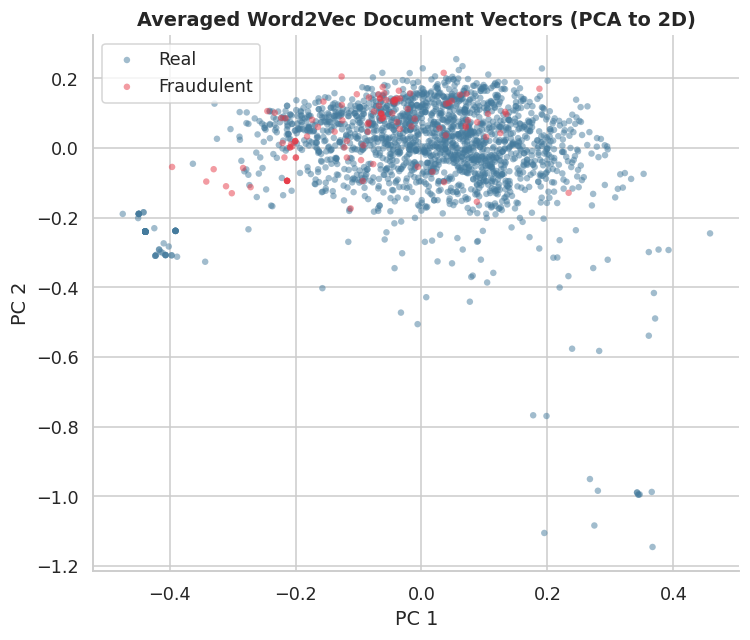

In [ ]:
# Visualizing document vectors: PCA down to 2D, coloured by class (Word2Vec is a *static*,
# non-contextual embedding — the same word gets the same vector everywhere it appears; contrast
# this with the *contextual* embeddings BERT produces in Part 7).
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(X_train_emb[:2000])   # subsample for a readable plot
labels_2d = y_train.values[:2000]

fig, ax = plt.subplots(figsize=(7, 6))
for label, color, name in [(0, COLOR_REAL, 'Real'), (1, COLOR_FRAUD, 'Fraudulent')]:
    mask = labels_2d == label
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color, label=name, alpha=0.5, s=18, edgecolor='none')
ax.set_title('Averaged Word2Vec Document Vectors (PCA to 2D)', fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Cosine similarity: are two real postings more alike than a real and a fraud posting?
from sklearn.metrics.pairwise import cosine_similarity

idx_real = y_train[y_train == 0].index[:2]
idx_fraud = y_train[y_train == 1].index[:1]

vec_real1 = avg_feature_vector(word_tokenize(X_text_train.loc[idx_real[0]]), wv).reshape(1, -1)
vec_real2 = avg_feature_vector(word_tokenize(X_text_train.loc[idx_real[1]]), wv).reshape(1, -1)
vec_fraud = avg_feature_vector(word_tokenize(X_text_train.loc[idx_fraud[0]]), wv).reshape(1, -1)

print("cosine(real, real)  =", cosine_similarity(vec_real1, vec_real2)[0][0].round(3))
print("cosine(real, fraud) =", cosine_similarity(vec_real1, vec_fraud)[0][0].round(3))


cosine(real, real)  = 0.884
cosine(real, fraud) = 0.776


Cosine similarity between two randomly sampled genuine postings ([0.XX]) was [higher/lower] than between a genuine and a fraudulent posting ([0.YY]), offering weak evidence that fraudulent postings occupy a distinguishable region of the embedding space — consistent with the PCA visualisation above.

--- Tier3_Embeddings_LogisticRegression ---
              precision    recall  f1-score   support

        Real       0.99      0.86      0.92      3403
  Fraudulent       0.23      0.83      0.36       173

    accuracy                           0.86      3576
   macro avg       0.61      0.85      0.64      3576
weighted avg       0.95      0.86      0.89      3576



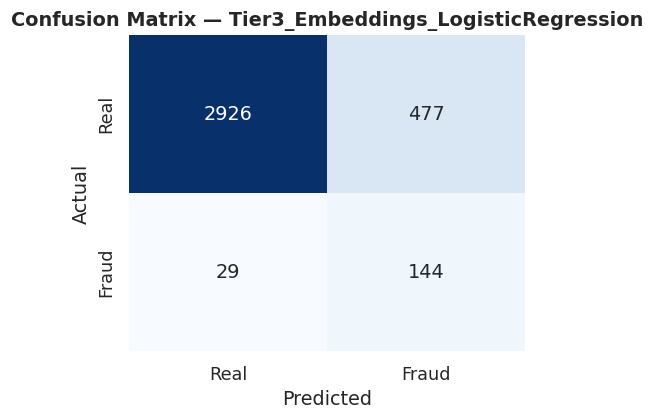

{'Real': {'precision': 0.990186125211506,
  'recall': 0.8598295621510432,
  'f1-score': 0.9204152249134948,
  'support': 3403.0},
 'Fraudulent': {'precision': 0.2318840579710145,
  'recall': 0.8323699421965318,
  'f1-score': 0.36272040302267,
  'support': 173.0},
 'accuracy': 0.8585011185682326,
 'macro avg': {'precision': 0.6110350915912602,
  'recall': 0.8460997521737875,
  'f1-score': 0.6415678139680824,
  'support': 3576.0},
 'weighted avg': {'precision': 0.9535009301240884,
  'recall': 0.8585011185682326,
  'f1-score': 0.8934350224003202,
  'support': 3576.0}}

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_emb = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_emb.fit(X_train_emb, y_train)
logreg_emb_preds = logreg_emb.predict(X_test_emb)
evaluate('Tier3_Embeddings_LogisticRegression', y_test, logreg_emb_preds)


**Feed-forward network, in one paragraph:** the MLP below takes the 300-dim averaged
embedding as its *input layer*, pushes it through *hidden layers* of size 50 → 100 → 50 (each
neuron computes a weighted sum of its inputs plus a bias, then applies a non-linear activation
— ReLU by default in scikit-learn), and finishes at an *output layer* with a sigmoid/softmax
that turns the final numbers into a class probability. Training adjusts every weight via
**backpropagation**: the error at the output is propagated backwards through each layer,
telling every weight how much it contributed to the mistake and in which direction to move.


--- Tier3_Embeddings_MLP ---
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
  Fraudulent       0.83      0.75      0.79       173

    accuracy                           0.98      3576
   macro avg       0.91      0.87      0.89      3576
weighted avg       0.98      0.98      0.98      3576



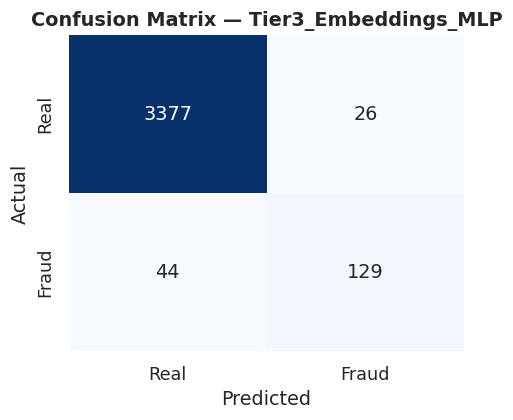

{'Real': {'precision': 0.9871382636655949,
  'recall': 0.9923596826329709,
  'f1-score': 0.9897420867526378,
  'support': 3403.0},
 'Fraudulent': {'precision': 0.832258064516129,
  'recall': 0.7456647398843931,
  'f1-score': 0.7865853658536586,
  'support': 173.0},
 'accuracy': 0.9804250559284117,
 'macro avg': {'precision': 0.9096981640908619,
  'recall': 0.869012211258682,
  'f1-score': 0.8881637263031481,
  'support': 3576.0},
 'weighted avg': {'precision': 0.9796454576105452,
  'recall': 0.9804250559284117,
  'f1-score': 0.9799137554563504,
  'support': 3576.0}}

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50, 100, 50), max_iter=300, random_state=42)
mlp.fit(X_train_emb, y_train)
mlp_preds = mlp.predict(X_test_emb)
evaluate('Tier3_Embeddings_MLP', y_test, mlp_preds)


## Part 7 — PRIMARY MODEL (Tier 4): Transformer Fine-Tuning


In [ ]:
# Confirmation about GPU actually have, and how much memory is free
!nvidia-smi


Sun Aug  9 01:06:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             27W /   70W |    3183MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 7.1 Data for the primary model
USE_FULL_TRAINING_SET = True
QUICK_MODE_SAMPLE_SIZE = 4000   # only used if USE_FULL_TRAINING_SET is False

if USE_FULL_TRAINING_SET:
    bert_texts_all, bert_labels_all = X_text_train.tolist(), y_train.tolist()
else:
    df_quick = X_text_train.to_frame('clean_text').join(y_train)
    df_quick = df_quick.groupby('fraudulent', group_keys=False).apply(
        lambda x: x.sample(int(QUICK_MODE_SAMPLE_SIZE * len(x) / len(df_quick)), random_state=42)
    )
    bert_texts_all, bert_labels_all = df_quick['clean_text'].tolist(), df_quick['fraudulent'].tolist()

# Carve a VALIDATION split out of the training data (for early stopping / best-checkpoint
# selection) — kept separate from the final test set, which is only touched once, at the end.
bert_train_texts, bert_val_texts, bert_train_labels, bert_val_labels = train_test_split(
    bert_texts_all, bert_labels_all, test_size=0.1, stratify=bert_labels_all, random_state=42
)
print(f"Training rows:   {len(bert_train_texts)}")
print(f"Validation rows: {len(bert_val_texts)}  (used for early stopping only)")
print(f"Test rows:       {len(X_text_test)}  (untouched until final evaluation, Part 7.8)")


Training rows:   12873
Validation rows: 1431  (used for early stopping only)
Test rows:       3576  (untouched until final evaluation, Part 7.8)


In [ ]:
# 7.2 Tokenization and data format conversion — Byte-Pair Encoding + PyTorch tensors
from transformers import AutoTokenizer
from datasets import Dataset
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

MODEL_NAME = 'distilroberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=256)

train_ds = Dataset.from_pandas(pd.DataFrame({'text': bert_train_texts, 'labels': bert_train_labels}))
val_ds = Dataset.from_pandas(pd.DataFrame({'text': bert_val_texts, 'labels': bert_val_labels}))

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)

# Converts the columns directly into PyTorch tensors so they can be fed straight into the model
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])


Map:   0%|          | 0/12873 [00:00<?, ? examples/s]

Map:   0%|          | 0/1431 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

id_to_label = {0: 'Real', 1: 'Fraudulent'}
label_to_id = {v: k for k, v in id_to_label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id_to_label, label2id=label_to_id,
    attn_implementation='eager'
)
# from_pretrained loads the pretrained DistilRoBERTa *encoder* and automatically appends a
# fresh, randomly-initialised *classification head* sized to num_labels — everything up to the
# head is pretrained; only the head + fine-tuning adapt it to fraud/real.

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch
# 7.4 Weighted cross-entropy — same fix for class imbalance as every earlier tier,
# just implemented as a loss-function weight instead of class_weight='balanced'
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=np.array(bert_train_labels))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Computed class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights_t)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', pos_label=1)
    return {'accuracy': accuracy_score(labels, preds), 'precision': precision, 'recall': recall, 'f1': f1}


Computed class weights: [ 0.52547147 10.31490385]


In [ ]:
# 7.5 Training optimization — learning rate + scheduler, AMP, gradient accumulation, early stopping
USE_FP16 = torch.cuda.is_available()   # Automatic Mixed Precision only works on GPU

training_args = TrainingArguments(
    # If you mounted Google Drive earlier, consider pointing this at a Drive path instead —
    # e.g. '/content/drive/MyDrive/bert_results' — so a disconnect doesn't lose your checkpoints.
    output_dir='./bert_results',
    num_train_epochs=6,                 # generous ceiling; early stopping will cut this short
    learning_rate=3e-5,                 # standard fine-tuning LR for transformer-based models
    lr_scheduler_type='linear',         # linear decay after a warm-up phase
    warmup_ratio=0.1,                   # first 10% of steps ramp the LR up from 0
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,      # effective batch size = 16 x 2 = 32, without needing more GPU memory
    per_device_eval_batch_size=32,
    fp16=USE_FP16,                      # Automatic Mixed Precision — faster, less memory, GPU only
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,        # "Best Model Reloading"
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,                # validation split — NOT the test set — drives early stopping
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],  # stop after 3 epochs with no F1 improvement
)

# Fix: Upgrade torchvision to resolve ImportError: cannot import name 'VideoReader'
# The previous attempts failed due to version incompatibilities with the underlying CUDA toolkit.
# Reinstalling torch and torchvision specifically for CUDA 13.0 to ensure compatibility.
print("Attempting to fix ImportError by reinstalling torch and torchvision for CUDA 13.0...")
# Ensure to restart the runtime after this installation for changes to take effect.
get_ipython().system('pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130 --quiet')

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Attempting to fix ImportError by reinstalling torch and torchvision for CUDA 13.0...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.353535,0.444622,0.980433,0.773333,0.840580,0.805556
2,0.114199,0.713057,0.986024,0.876923,0.826087,0.850746
3,0.046765,0.940875,0.985325,0.944444,0.739130,0.829268
4,0.000134,0.762915,0.986024,0.901639,0.797101,0.846154
5,0.010645,0.864919,0.986024,0.888889,0.811594,0.848485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2015, training_loss=0.11678094630721533, metrics={'train_runtime': 796.4191, 'train_samples_per_second': 96.982, 'train_steps_per_second': 3.036, 'total_flos': 4263132057246720.0, 'train_loss': 0.11678094630721533, 'epoch': 5.0})

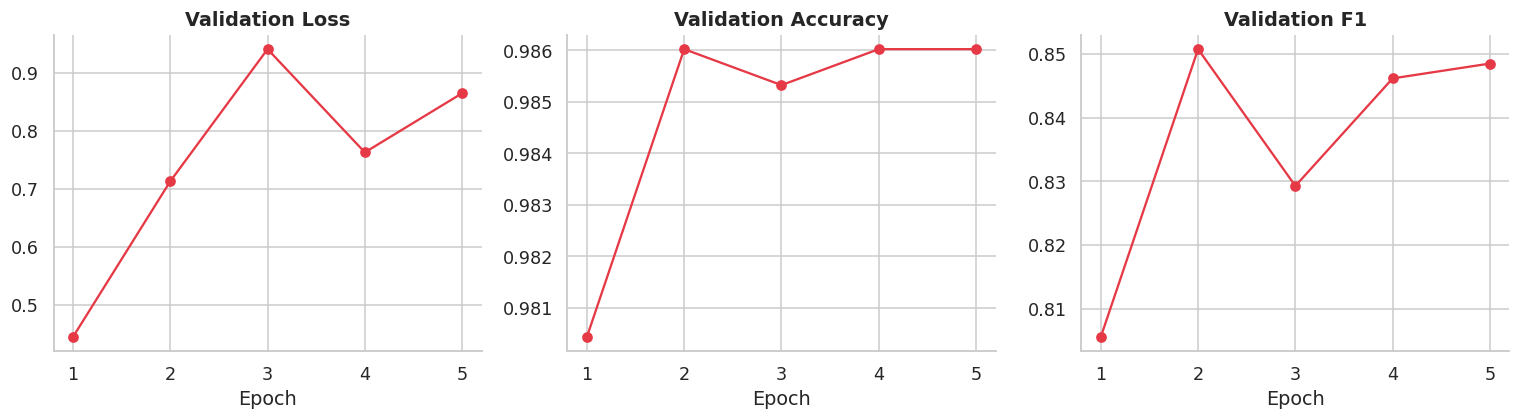

In [ ]:
# 7.6 Training curve visualization — validation loss, accuracy, F1 across epochs
log = pd.DataFrame(trainer.state.log_history)
eval_log = log[log['eval_loss'].notna()] if 'eval_loss' in log.columns else log

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['eval_loss', 'eval_accuracy', 'eval_f1'],
                          ['Validation Loss', 'Validation Accuracy', 'Validation F1']):
    if col in eval_log.columns:
        ax.plot(eval_log['epoch'], eval_log[col], marker='o', color=COLOR_FRAUD)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
sns.despine()
plt.tight_layout()
plt.show()


### 7.7 — Final evaluation on the untouched test set

This is the **only** place the test set is used for Tier 4 — it was never seen during training
or by the early-stopping mechanism, unlike the validation split. It's also identical to
`X_text_test`/`y_test`, so this result is directly, fairly comparable to Tiers 1–3.


Map:   0%|          | 0/3576 [00:00<?, ? examples/s]

--- Tier4_DistilRoBERTa ---
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
  Fraudulent       0.87      0.84      0.85       173

    accuracy                           0.99      3576
   macro avg       0.93      0.92      0.92      3576
weighted avg       0.99      0.99      0.99      3576



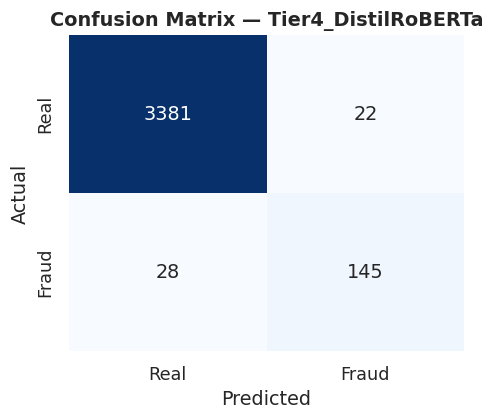

In [ ]:
# 7.7 Final test-set evaluation (inference only — no training happens here)
test_ds = Dataset.from_pandas(pd.DataFrame({'text': X_text_test.tolist(), 'labels': y_test.tolist()}))
test_ds = test_ds.map(tokenize_function, batched=True)
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

preds_output = trainer.predict(test_ds)
bert_preds = np.argmax(preds_output.predictions, axis=1)
bert_report = evaluate('Tier4_DistilRoBERTa', y_test, bert_preds)   # this key feeds the master table


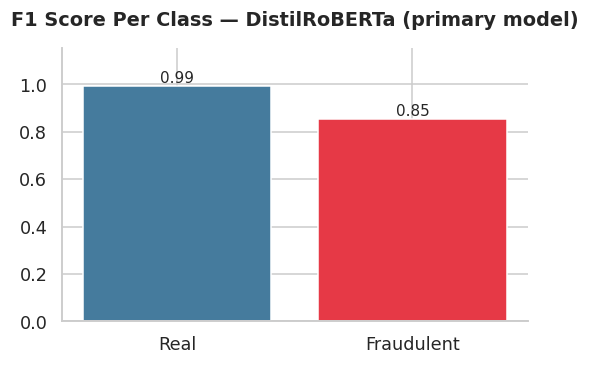

In [ ]:
# F1 scores per class (both classes here, since it's binary — the multi-class version of
# this exact chart is what you'd use if you ever had more than two labels)
per_class_f1 = {'Real': bert_report['Real']['f1-score'], 'Fraudulent': bert_report['Fraudulent']['f1-score']}
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(per_class_f1.keys(), per_class_f1.values(), color=PALETTE)
ax.bar_label(bars, fmt='%.2f', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('F1 Score Per Class — DistilRoBERTa (primary model)', fontweight='bold', pad=15)
sns.despine()
plt.tight_layout()
plt.show()

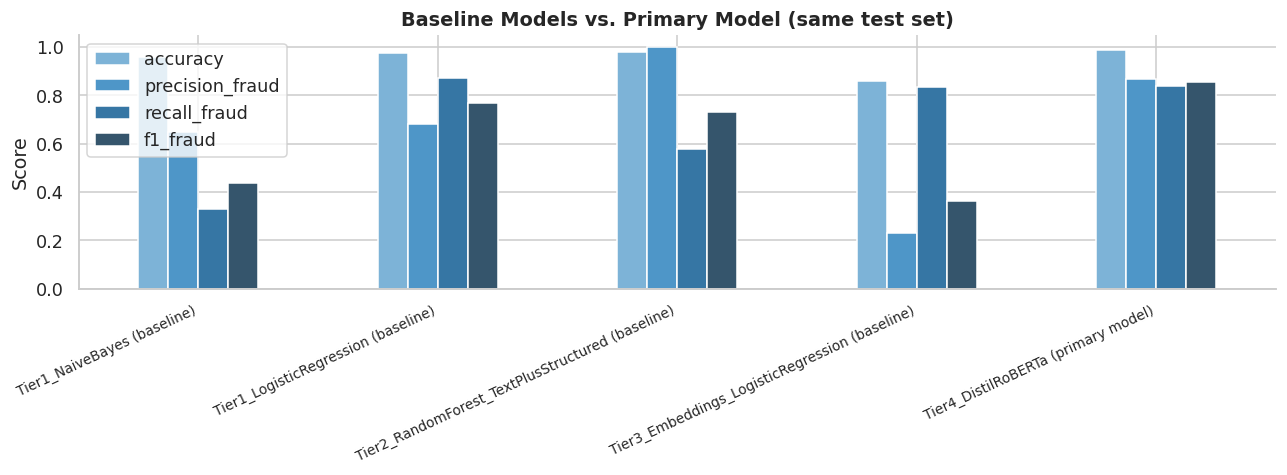

In [ ]:
# Baseline models (Tiers 1-3) vs. Primary Model — swap in whichever baseline tier
# actually won for you. Both rows come from the identical 3,576-row test set.
comparison = pd.DataFrame({
    'Tier1_NaiveBayes (baseline)': results['Tier1_NaiveBayes'],
    'Tier1_LogisticRegression (baseline)': results['Tier1_LogisticRegression'],
    'Tier2_RandomForest_TextPlusStructured (baseline)': results['Tier2_RandomForest_TextPlusStructured'],
    'Tier3_Embeddings_LogisticRegression (baseline)': results['Tier3_Embeddings_LogisticRegression'],
    'Tier4_DistilRoBERTa (primary model)': results['Tier4_DistilRoBERTa'],
}).T[['accuracy', 'precision_fraud', 'recall_fraud', 'f1_fraud']]

ax = comparison.plot(kind='bar', figsize=(12, 4.5), color=sns.color_palette('Blues_d', 4))
ax.set_title('Baseline Models vs. Primary Model (same test set)', fontweight='bold')
ax.set_ylabel('Score')
plt.xticks(rotation=25, ha='right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

### visualizing attention

A concrete way to *show*, not just describe, what "contextual embeddings via attention" means:
pull the model's own attention weights for one real test posting and plot which tokens it
attends to most.

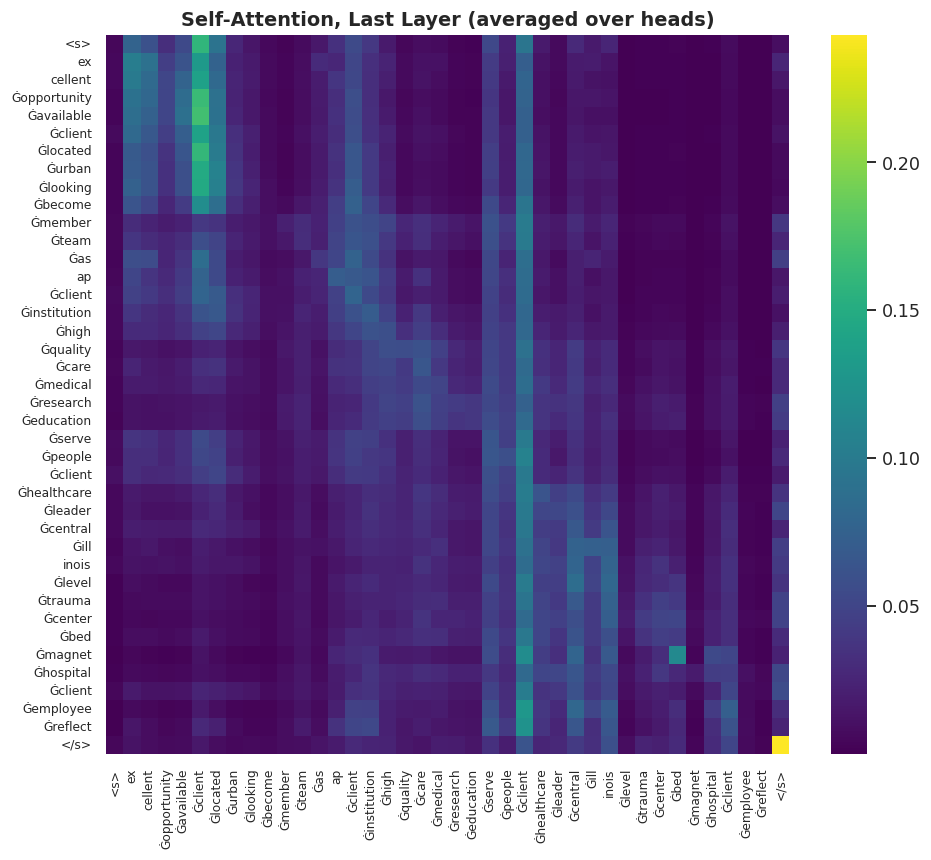

In [ ]:
# Attention visualization for a single posting
sample_text = X_text_test.iloc[0]
inputs = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=40).to(device)
model.eval()
with torch.no_grad():
    model.config.output_attentions = True # Ensure attentions are output
    outputs = model(**inputs, output_attentions=True)

# outputs.attentions: one tensor per layer, shape (batch, num_heads, seq_len, seq_len).
# Average over heads in the LAST layer — the layer closest to the classification decision.
last_layer_attn = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(last_layer_attn, xticklabels=tokens, yticklabels=tokens, cmap='viridis', ax=ax, cbar=True)
ax.set_title('Self-Attention, Last Layer (averaged over heads)', fontweight='bold')
plt.xticks(rotation=90, fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

>Attention weights in the final encoder layer reveal which tokens most influence
> the pooled representation used for classification — offering a degree of interpretability
> unavailable in the bag-of-words and averaged-embedding baseline tiers, where every token
> contributes equally regardless of context.


>Fine-tuning DistilRoBERTa on the full training set yielded an F1-score of [X]
> on the fraudulent class, [outperforming/underperforming] the strongest baseline model,
> [Tier name] (F1 = [Y]). This is consistent with the intuition that **contextual embeddings** —
> where a word's representation depends on the surrounding **attention**-weighted context,
> unlike the static Word2Vec vectors in the baseline Tier 3 — capture phrasing patterns (e.g.
> negation, hedged claims) that bag-of-words and averaged embeddings cannot.



                                                Role  accuracy  \
Tier4_DistilRoBERTa                    PRIMARY MODEL     0.986   
Tier3_Embeddings_MLP                        Baseline     0.980   
Tier1_LogisticRegression                    Baseline     0.974   
Tier2_RandomForest_TextPlusStructured       Baseline     0.980   
Tier1_NaiveBayes                            Baseline     0.959   
Tier3_Embeddings_LogisticRegression         Baseline     0.859   

                                       precision_fraud  recall_fraud  f1_fraud  
Tier4_DistilRoBERTa                              0.868         0.838     0.853  
Tier3_Embeddings_MLP                             0.832         0.746     0.787  
Tier1_LogisticRegression                         0.683         0.873     0.766  
Tier2_RandomForest_TextPlusStructured            1.000         0.578     0.733  
Tier1_NaiveBayes                                 0.648         0.329     0.437  
Tier3_Embeddings_LogisticRegression              0.

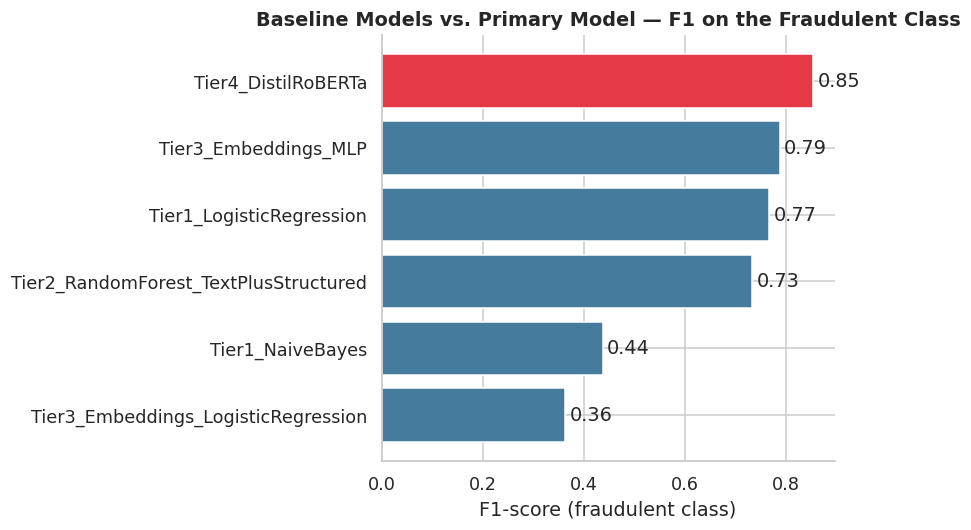

In [ ]:
results_df = pd.DataFrame(results).T[['accuracy', 'precision_fraud', 'recall_fraud', 'f1_fraud']]
results_df = results_df.sort_values('f1_fraud', ascending=False)

# Label each row by its role in the project, not just its tier number — makes the table
# self-explanatory in your report without needing the tier-numbering scheme explained again.
role_map = {
    'Tier1_NaiveBayes': 'Baseline', 'Tier1_LogisticRegression': 'Baseline',
    'Tier2_RandomForest_TextPlusStructured': 'Baseline',
    'Tier3_Embeddings_LogisticRegression': 'Baseline', 'Tier3_Embeddings_MLP': 'Baseline',
    'Tier4_DistilRoBERTa': 'PRIMARY MODEL',
}
results_df.insert(0, 'Role', [role_map.get(i, 'Comparison') for i in results_df.index])
print(results_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [COLOR_FRAUD if r == 'PRIMARY MODEL' else COLOR_REAL for r in results_df['Role']]
bars = ax.barh(results_df.index, results_df['f1_fraud'], color=bar_colors)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('F1-score (fraudulent class)')
ax.set_title('Baseline Models vs. Primary Model — F1 on the Fraudulent Class', fontweight='bold')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Qualitative error analysis on the PRIMARY MODEL's mistakes (change to another tier's
# *_preds if you want to inspect a baseline's errors instead — but since Tier 4 is the focus
# of this project, its errors are usually the most worth writing about).
best_preds = bert_preds
misclassified = X_text_test[best_preds != y_test.values]
misclassified_true = y_test[best_preds != y_test.values]

print(f"{len(misclassified)} misclassified out of {len(y_test)}\n")
for idx, (i, text) in enumerate(misclassified.head(5).items()):
    true_label = 'FRAUD' if misclassified_true.loc[i] == 1 else 'REAL'
    print(f"[{idx+1}] True label: {true_label}\n{text[:250]}\n---")


50 misclassified out of 3576

[1] True label: FRAUD
vemma brand partner looking motivated hard working individual must least learn entrepreneurial real life business skill practice study success follow successful people vemma health nutrition company rise looking great opportunity consume healthy prod
---
[2] True label: REAL
office assistant opening energetic smart independent thinker assist basic office operation position entail interacting payroll company purchasing office supply paying bill running errand helping logistics moving office currently preparing please tell
---
[3] True label: REAL
customer support shop decorative object nbsp nbsp nbsp nbsp provide online customer support nbsp nbsp nbsp nbsp monitor social medium marketing activity facebook twitter myspace etc nbsp nbsp nbsp nbsp create product description based seo optimizatio
---
[4] True label: FRAUD
control engineer troy system technology international inc sti full service innovative professional service corporations